# Bridging Silence — TSL Word Recognition Training Pipeline

This notebook implements the training pipeline defined in `trainng.md`.
It uses a **CNN + BiLSTM** architecture without Kalman filtering to establish a strong baseline.

**Pipeline Steps:**
1. Setup & Imports
2. Configuration
3. Sequence Processing (Missing frames, Padding, Resampling)
4. Dataset Splitting (70% Train, 15% Val, 15% Test)
5. Model Architecture
6. Training Configuration
7. Training
8. Evaluation (Accuracy, Confusion Matrix, Classification Report)

In [2]:
%pip install seaborn


  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
 

In [2]:
%pip install tensorflow


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.35.1 which is incompatible.


In [4]:
%pip install scikit-learn  

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 840.2 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.9 MB 763.2 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.9 MB 763.2 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/8.9 MB 774.0 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/8.9 MB 808.5 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/8.9 MB 808.5 kB/

In [1]:
# ==========================================
# 1. Setup & Imports
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress TensorFlow warnings for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [2]:
# ==========================================
# 2. Configuration & Constants
# ==========================================

# Directory containing processed landmarks (.npy files)
DATA_DIR = "processed_data/landmarks"

# Target sequence length and features as defined in training.md
MAX_SEQ_LENGTH = 90
FEATURES = 141

# Training Hyperparameters
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.001

In [3]:
# ==========================================
# 3. Sequence Processing
# ==========================================

def process_sequence(seq, target_length=MAX_SEQ_LENGTH):
    """
    Process a single landmark sequence according to training.md rules:
    1. Forward fill internal missing frames to avoid [0,0,0] artificial motion.
    2. Standardize to target_length (pad with zeros if short, temporal sample if long).
    """
    # 1. Identify the actual length of the sequence before any zero-padding
    # (Find the last frame that is not all zeros)
    non_zero_frames = [i for i, frame in enumerate(seq) if np.any(frame != 0)]
    if len(non_zero_frames) == 0:
        # If the entire sequence is empty, return an empty padded array
        return np.zeros((target_length, FEATURES))
        
    actual_len = non_zero_frames[-1] + 1
    seq = seq[:actual_len].copy() # Slice off trailing zero-padding
    
    # 2. Forward fill internal missing frames
    for i in range(1, len(seq)):
        if np.all(seq[i] == 0):
            seq[i] = seq[i-1] # Reuse previous frame
            
    # 3. Standardize length to MAX_SEQ_LENGTH (90)
    if len(seq) < target_length:
        # If shorter, pad with zeros at the end
        padding = np.zeros((target_length - len(seq), FEATURES))
        seq = np.vstack([seq, padding])
    elif len(seq) > target_length:
        # If longer, use temporal sampling to downsample to target_length
        indices = np.linspace(0, len(seq) - 1, target_length).astype(int)
        seq = seq[indices]
        
    return seq

def build_dataset(data_dir):
    """
    Load all .npy files, process them, and build the X and y datasets.
    """
    X, y = [], []
    
    if not os.path.exists(data_dir):
        print(f"Warning: Directory '{data_dir}' not found.")
        return np.array(X), np.array(y), {}

    classes = sorted(os.listdir(data_dir))
    class_map = {cls_name: i for i, cls_name in enumerate(classes)}

    for cls_name in classes:
        cls_dir = os.path.join(data_dir, cls_name)
        if not os.path.isdir(cls_dir): 
            continue
            
        for npy_file in os.listdir(cls_dir):
            if npy_file.endswith('.npy'):
                filepath = os.path.join(cls_dir, npy_file)
                seq = np.load(filepath)
                
                # Apply sequence processing rules
                seq = process_sequence(seq)
                
                X.append(seq)
                y.append(class_map[cls_name])

    X = np.array(X)
    y = np.array(y)
    
    return X, y, class_map

# Build the dataset
X, y, class_map = build_dataset(DATA_DIR)
classes = list(class_map.keys())

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Classes: {class_map}")

Dataset shape: (38, 90, 141)
Labels shape: (38,)
Classes: {'JINA': 0, 'KUJITAMBULISHA': 1}


In [4]:
# ==========================================
# 4. Dataset Split (70% Train, 15% Val, 15% Test)
# ==========================================

if len(X) > 0:
    # First split: Separate out 15% for the Test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, 
        test_size=0.15, 
        random_state=42, 
        stratify=y
    )

    # Second split: Separate the remaining 85% into Train (70%) and Val (15%)
    # 0.15 / 0.85 ≈ 0.1764 (which represents the 15% validation slice out of the remaining 85%)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, 
        test_size=(0.15 / 0.85), 
        random_state=42, 
        stratify=y_temp
    )

    print(f"Training set:   {X_train.shape}")
    print(f"Validation set: {X_val.shape}")
    print(f"Testing set:    {X_test.shape}")
else:
    print("No data found to split. Make sure data is collected and processed.")

Training set:   (26, 90, 141)
Validation set: (6, 90, 141)
Testing set:    (6, 90, 141)


In [5]:
# ==========================================
# 5. Model Architecture (CNN + BiLSTM)
# ==========================================

num_classes = len(class_map) if class_map else 0

model = Sequential([
    # Temporal Convolutional Layers to extract local spatial-temporal features
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(MAX_SEQ_LENGTH, FEATURES)),
    BatchNormalization(),
    
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    
    # Bidirectional LSTM layers to capture forward and backward long-term dependencies
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    
    # Fully connected Dense layers for classification
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

d:\BRIDGING SILENCE DATA COLLECTION PIPELINE\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 88, 64)         │        27,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 88, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 86, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,002 (1.86 MB)

 Trainable params: 487,874 (1.86 MB)

 Non-trainable params: 128 (512.00 B)

In [6]:
# ==========================================
# 6. Training Configuration
# ==========================================

# Adam optimizer with specified learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy', # Used because labels are integers (0, 1, 2...)
    metrics=['accuracy']
)

# Stop training early if validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when learning stagnates to help the model converge
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

In [7]:
# ==========================================
# 7. Model Training
# ==========================================

if len(X) > 0:
    print("Starting training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping, reduce_lr]
    )
    
    # Save the model after training
    model.save("tsl_word_model.h5")
    print("\nModel saved as 'tsl_word_model.h5'")
else:
    print("Cannot train model: No data available.")

Starting training...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 547ms/step - accuracy: 0.6154 - loss: 0.6565 - val_accuracy: 0.5000 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.8462 - loss: 0.5014 - val_accuracy: 0.8333 - val_loss: 0.6471 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - accuracy: 0.8846 - loss: 0.3491 - val_accuracy: 0.8333 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.9615 - loss: 0.1866 - val_accuracy: 0.8333 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.9231 - loss: 0.2294 - val_accuracy: 1.0000 - val_loss: 0.1557 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.9615 - loss: 0.1508 - val_accuracy: 0.8333 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.9231 - 


Model saved as 'tsl_word_model.h5'



Test Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Classification Report:
                precision    recall  f1-score   support

          JINA       1.00      1.00      1.00         3
KUJITAMBULISHA       1.00      1.00      1.00         3

      accuracy                           1.00         6
     macro avg       1.00      1.00      1.00         6
  weighted avg       1.00      1.00      1.00         6



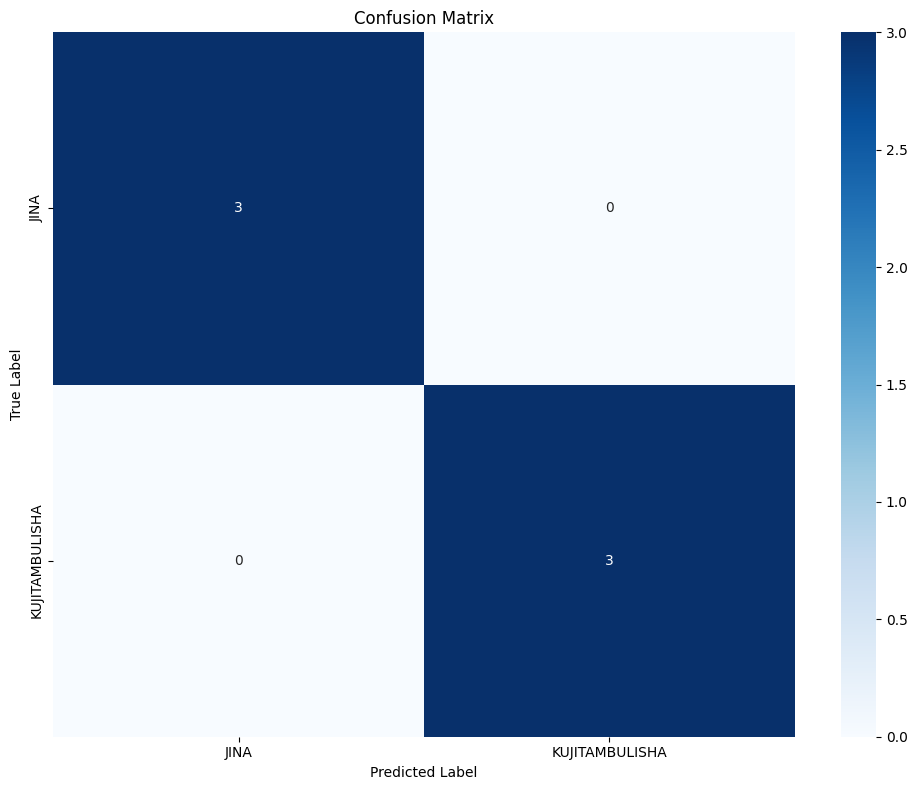

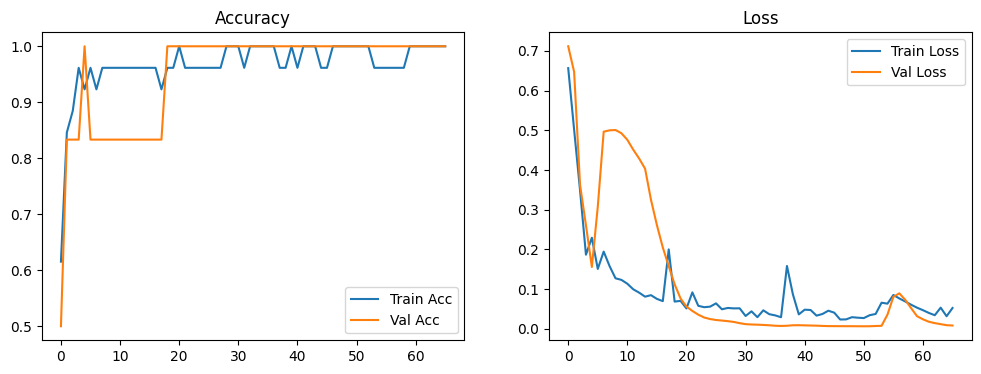

In [8]:
# ==========================================
# 8. Evaluation & Metrics
# ==========================================

if len(X) > 0:
    # 1. Overall Accuracy on Test Set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.4f}")

    # 2. Get predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 3. Classification Report (Precision, Recall, F1-Score per class)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))

    # 4. Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Plot Training History
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()


## 9. Test the Model on a Single Sample

Use this cell to run inference on **any saved `.npy` landmark file** and inspect the prediction.  
Set `TEST_SAMPLE_PATH` to the path of the `.npy` file you want to test.


Model loaded from 'tsl_word_model.h5'
Raw shape: (120, 141)
Processed shape: (90, 141)

Prediction : KUJITAMBULISHA
Confidence : 99.67%

Top-3 Predictions:
  1. KUJITAMBULISHA       99.67%
  2. JINA                 0.33%


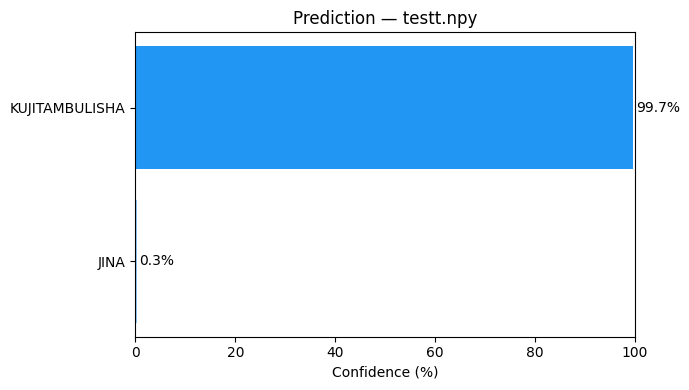

In [11]:
# ==========================================
# 9. Test the Model on a Single Sample
# ==========================================

# Set this to any .npy file you want to test
# e.g. 'processed_data/landmarks/hello/sample_001.npy'
TEST_SAMPLE_PATH = 'testt.npy'
MODEL_PATH = 'tsl_word_model.h5'

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

if not os.path.exists(MODEL_PATH):
    print(f"Model file '{MODEL_PATH}' not found. Run Cell 7 first.")
else:
    loaded_model = tf.keras.models.load_model(MODEL_PATH)
    print(f"Model loaded from '{MODEL_PATH}'")

    # Build index → label map
    try:
        idx_to_class = {v: k for k, v in class_map.items()}
    except NameError:
        data_dir = 'processed_data/landmarks'
        if os.path.exists(data_dir):
            idx_to_class = {i: c for i, c in enumerate(sorted(os.listdir(data_dir)))}
        else:
            idx_to_class = {}
            print("Warning: could not rebuild class map, DATA_DIR not found.")

    if not TEST_SAMPLE_PATH:
        print("Set TEST_SAMPLE_PATH to a .npy file and re-run.")
    elif not os.path.exists(TEST_SAMPLE_PATH):
        print(f"File not found: '{TEST_SAMPLE_PATH}'")
    else:
        SEQ_LEN = 90
        FEATS   = 141

        raw_seq = np.load(TEST_SAMPLE_PATH)
        print(f"Raw shape: {raw_seq.shape}")

        # Same preprocessing as training
        try:
            processed = process_sequence(raw_seq)
        except NameError:
            def _process(seq):
                nzf = [i for i, f in enumerate(seq) if np.any(f != 0)]
                if not nzf:
                    return np.zeros((SEQ_LEN, FEATS))
                seq = seq[:nzf[-1] + 1].copy()
                for i in range(1, len(seq)):
                    if np.all(seq[i] == 0):
                        seq[i] = seq[i - 1]
                if len(seq) < SEQ_LEN:
                    seq = np.vstack([seq, np.zeros((SEQ_LEN - len(seq), FEATS))])
                else:
                    idx = np.linspace(0, len(seq) - 1, SEQ_LEN).astype(int)
                    seq = seq[idx]
                return seq
            processed = _process(raw_seq)

        print(f"Processed shape: {processed.shape}")

        sample = np.expand_dims(processed, axis=0)  # (1, 90, 141)

        # Run inference
        probs      = loaded_model.predict(sample, verbose=0)[0]
        pred_idx   = int(np.argmax(probs))
        pred_label = idx_to_class.get(pred_idx, f"class_{pred_idx}")
        confidence = probs[pred_idx] * 100

        print(f"\nPrediction : {pred_label}")
        print(f"Confidence : {confidence:.2f}%")

        # Top-3
        top3_idx    = np.argsort(probs)[::-1][:3]
        top3_labels = [idx_to_class.get(i, f"class_{i}") for i in top3_idx]
        top3_probs  = probs[top3_idx] * 100

        print("\nTop-3 Predictions:")
        for rank, (lbl, p) in enumerate(zip(top3_labels, top3_probs), 1):
            print(f"  {rank}. {lbl:<20s} {p:.2f}%")

        # Bar chart
        colors = ['#2196F3' if i == pred_idx else '#90CAF9' for i in top3_idx]
        plt.figure(figsize=(7, 4))
        bars = plt.barh(top3_labels[::-1], top3_probs[::-1], color=colors[::-1])
        plt.xlabel('Confidence (%)')
        plt.title(f"Prediction — {os.path.basename(TEST_SAMPLE_PATH)}")
        plt.xlim(0, 100)
        for bar, p in zip(bars, top3_probs[::-1]):
            plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                     f'{p:.1f}%', va='center', fontsize=10)
        plt.tight_layout()
        plt.show()


In [5]:
%pip install protobuf==4.25.9


  Using cached protobuf-4.25.9-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp310-abi3-win_amd64.whl (413 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 4.25.9 which is incompatible.


In [7]:
%pip uninstall -y tensorflow protobuf 

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Found existing installation: protobuf 4.25.9
Uninstalling protobuf-4.25.9:
  Successfully uninstalled protobuf-4.25.9
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [8]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl (439 kB)

   ---------------------------------------- 0/2 [protobuf]
   ---------------------------------------- 0/2 [protobuf]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2 [tensorflow]
   -------------------- ------------------- 1/2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.35.1 which is incompatible.
